# Day 47 — Naive Bayes

### The idea in one sentence
> Use **probability**: for each class, ask *"how likely is this customer, if they were a buyer?"* and
> *"how likely, if they were not?"*, then pick the class with the higher probability.

It is based on **Bayes' theorem** and makes one simplifying ("naive") assumption: the features are independent of
each other within each class.

### The problem (same as Days 45–46)
Predict whether a social-network user **buys an SUV** (1) or not (0) from **Age** and **Estimated Salary**.

### In this notebook
1. Train Gaussian Naive Bayes and evaluate it
2. **Look inside the model**: what did it actually learn?
3. **Compute one prediction by hand** and check it against scikit-learn
4. Does Naive Bayes need feature scaling? (an experiment)
5. Bonus: a tiny **spam filter**, the classic use of Naive Bayes

> 📖 Theory: [`theory.md`](theory.md) · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

## 1. Load and split the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = ['#FA8072', '#1E90FF']          # 0 = did not buy (salmon), 1 = bought (blue)
CMAP = ListedColormap(COLORS)

In [2]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values      # Age, EstimatedSalary
y = dataset.iloc[:, -1].values       # Purchased (0 / 1)
print(dataset.shape)
dataset.head()

(400, 3)


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


> ✍️ **Core code: learn this.** 75% train, 25% test.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
print(X_train.shape, X_test.shape)

(300, 2) (100, 2)


## 2. Feature scaling
We scale to keep the same workflow as Days 45–46. In Section 7 we will test whether Naive Bayes actually needs it.

In [4]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

## 3. Train Gaussian Naive Bayes

**Gaussian** NB assumes that, within each class, every feature follows a **normal (bell-shaped) distribution**.
That suits numeric features like age and salary. Training just means computing, for each class:
- how common the class is (the **prior**)
- the **mean** and **variance** of each feature

> ✍️ **Core code: learn this.** Create and train the model. There are no hyperparameters to tune.

In [5]:
from sklearn.naive_bayes import GaussianNB

classifier = GaussianNB()
classifier.fit(X_train_sc, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[189.,111.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.63,0.37]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 2)","[[-0.46,-0.27], [ 0.78, 0.46]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 2)","[[0.6 ,0.51], [0.72,1.5 ]]"


## 4. Predict a new customer

> ✍️ **Core code: learn this.** `predict_proba` gives the probability of each class: Naive Bayes is a probabilistic model.

In [6]:
for age, salary in [(30, 87000), (50, 120000)]:
    x = sc.transform([[age, salary]])
    p = classifier.predict_proba(x)[0]
    print(f"Age {age}, salary {salary:>7,}: prediction = {classifier.predict(x)[0]}   "
          f"P(no) = {p[0]:.3f}, P(yes) = {p[1]:.3f}")

Age 30, salary  87,000: prediction = 0   P(no) = 0.902, P(yes) = 0.098
Age 50, salary 120,000: prediction = 1   P(no) = 0.027, P(yes) = 0.973


## 5. Evaluate on the test set

> ✍️ **Core code: learn this.** Confusion matrix, accuracy, precision and recall.

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = classifier.predict(X_test_sc)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred, target_names=['did not buy', 'bought']))

Confusion matrix:
 [[65  3]
 [ 7 25]]

Accuracy: 0.9

               precision    recall  f1-score   support

 did not buy       0.90      0.96      0.93        68
      bought       0.89      0.78      0.83        32

    accuracy                           0.90       100
   macro avg       0.90      0.87      0.88       100
weighted avg       0.90      0.90      0.90       100



> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

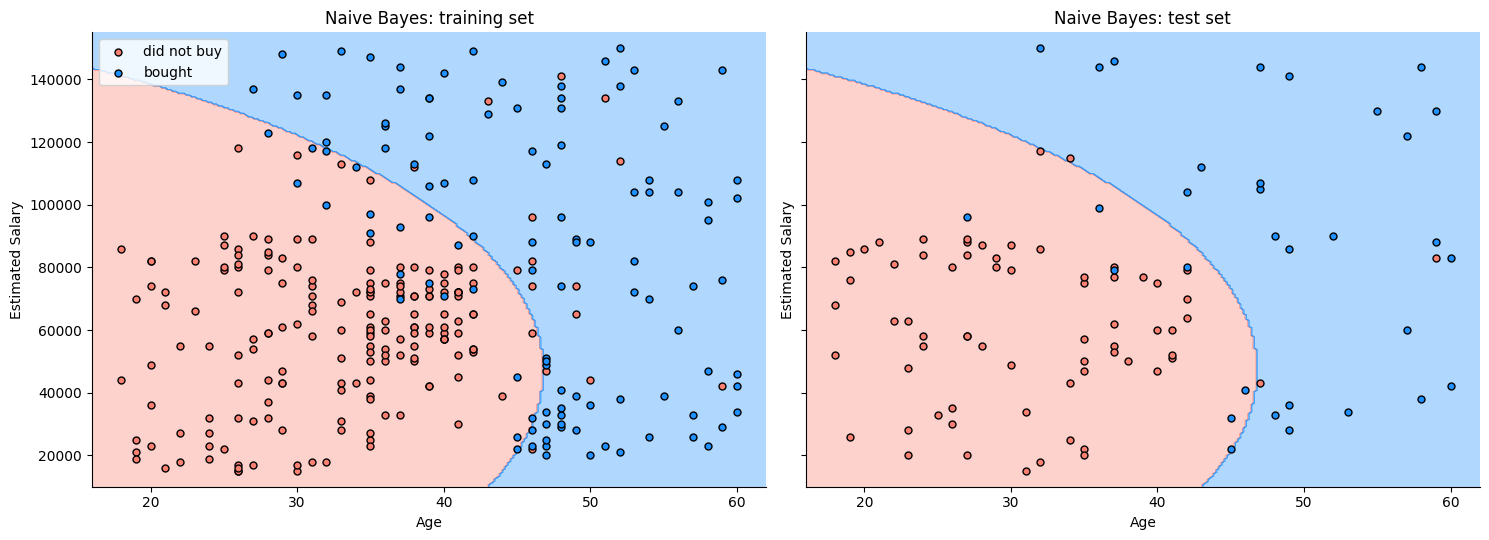

In [8]:
def plot_boundary(ax, model, X_raw, y, transform=None, title=''):
    # Colour every point of a grid by the model's prediction, then draw the real points on top.
    a = np.linspace(X_raw[:, 0].min() - 2, X_raw[:, 0].max() + 2, 250)
    s = np.linspace(X_raw[:, 1].min() - 5000, X_raw[:, 1].max() + 5000, 250)
    A, S = np.meshgrid(a, s)
    grid = np.c_[A.ravel(), S.ravel()]
    if transform is not None:
        grid = transform(grid)
    Z = model.predict(grid).reshape(A.shape)
    ax.contourf(A, S, Z, alpha=0.35, cmap=CMAP)
    for label in [0, 1]:
        ax.scatter(X_raw[y == label, 0], X_raw[y == label, 1], color=COLORS[label], edgecolor='k',
                   s=25, label=['did not buy', 'bought'][label])
    ax.set_xlabel('Age')
    ax.set_ylabel('Estimated Salary')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
plot_boundary(axes[0], classifier, X_train, y_train, sc.transform, 'Naive Bayes: training set')
plot_boundary(axes[1], classifier, X_test, y_test, sc.transform, 'Naive Bayes: test set')
axes[0].legend()
plt.tight_layout()
plt.show()

**90% accuracy**, and the boundary is a smooth **curve**, not a straight line. It comes from comparing two bell-shaped
distributions (one per class) with different spreads.

## 6. Look inside the model: what did it learn?

Everything Naive Bayes knows fits in one small table. We train it on the **unscaled** data so the numbers are in
real units (years and salary).

> ✍️ **Core code: learn this.** The learned parameters: priors, means and standard deviations.

In [9]:
nb_raw = GaussianNB().fit(X_train, y_train)

summary = pd.DataFrame({
    'prior P(class)': nb_raw.class_prior_,
    'mean Age': nb_raw.theta_[:, 0],
    'std Age': np.sqrt(nb_raw.var_[:, 0]),
    'mean Salary': nb_raw.theta_[:, 1],
    'std Salary': np.sqrt(nb_raw.var_[:, 1]),
}, index=['did not buy (0)', 'bought (1)']).round(2)
summary

,prior P(class),mean Age,std Age,mean Salary,std Salary
did not buy (0),0.63,33.51,7.90,60179.89,24557.88
bought (1),0.37,45.99,8.62,85594.59,42206.57


Read it like a story:
- **63%** of training users did not buy, **37%** bought: the **priors**.
- Non-buyers are on average **≈ 33 years** old with a salary of **≈ 60,000**.
- Buyers are on average **≈ 46 years** old with a salary of **≈ 86,000**, and their salaries vary much more.

Here are those bell curves:

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

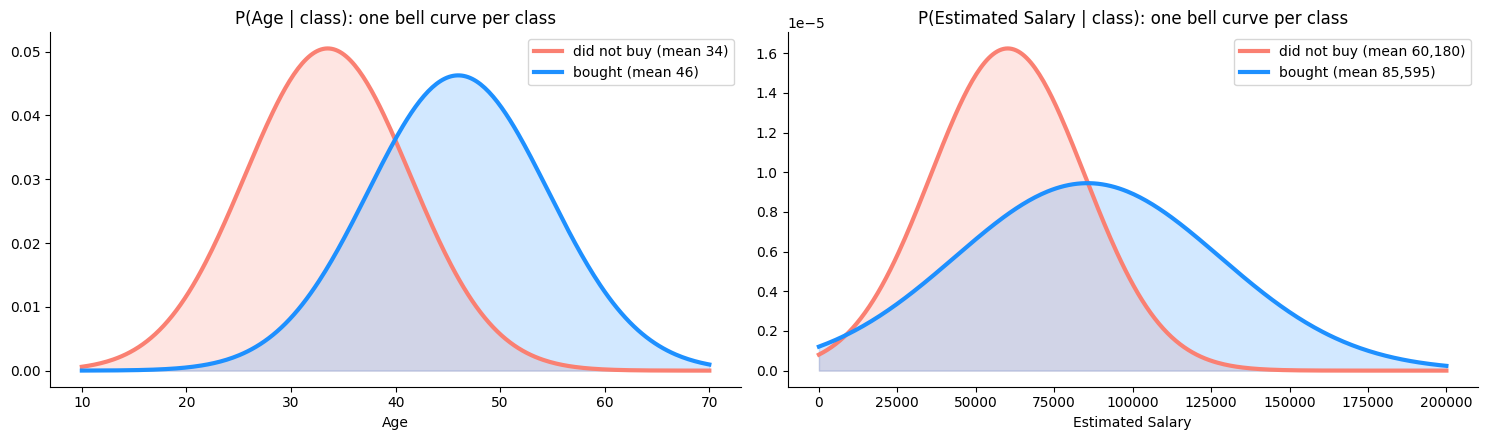

In [10]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, j, name, rng in [(axes[0], 0, 'Age', np.linspace(10, 70, 300)),
                          (axes[1], 1, 'Estimated Salary', np.linspace(0, 200000, 300))]:
    for c in [0, 1]:
        mu, sd = nb_raw.theta_[c, j], np.sqrt(nb_raw.var_[c, j])
        ax.plot(rng, norm.pdf(rng, mu, sd), color=COLORS[c], linewidth=3,
                label=f"{['did not buy', 'bought'][c]} (mean {mu:,.0f})")
        ax.fill_between(rng, norm.pdf(rng, mu, sd), color=COLORS[c], alpha=0.2)
    ax.set_title(f'P({name} | class): one bell curve per class')
    ax.set_xlabel(name)
    ax.legend()
plt.tight_layout()
plt.show()

For a new customer, Naive Bayes reads off **how high each curve is** at their age and salary, then combines
those heights with the priors.

## 7. One prediction by hand

New customer: **Age 30, Salary 87,000**. Bayes' rule (theory §3):

$$
P(\text{class} \mid \text{data}) \;\propto\; P(\text{class}) \times P(\text{Age} \mid \text{class}) \times P(\text{Salary} \mid \text{class})
$$

Each $P(\text{feature} \mid \text{class})$ is the height of the bell curve, from the normal-distribution formula
$\;f(x) = \frac{1}{\sqrt{2\pi\sigma^2}}\, e^{-\frac{(x-\mu)^2}{2\sigma^2}}$.

> ✍️ **Core code: learn this.** Bayes' rule, step by step.

In [11]:
def gaussian(x, mean, var):
    return np.exp(-(x - mean) ** 2 / (2 * var)) / np.sqrt(2 * np.pi * var)

age, salary = 30, 87000
scores = []
for c in [0, 1]:
    prior = nb_raw.class_prior_[c]
    p_age = gaussian(age, nb_raw.theta_[c, 0], nb_raw.var_[c, 0])
    p_salary = gaussian(salary, nb_raw.theta_[c, 1], nb_raw.var_[c, 1])
    score = prior * p_age * p_salary
    scores.append(score)
    print(f"class {c}: prior {prior:.3f} x P(age) {p_age:.5f} x P(salary) {p_salary:.3e} = {score:.3e}")

scores = np.array(scores)
print("\nNormalised (divide by the sum):", (scores / scores.sum()).round(4))
print("scikit-learn predict_proba    :", nb_raw.predict_proba([[age, salary]])[0].round(4))

class 0: prior 0.630 x P(age) 0.04575 x P(salary) 8.948e-06 = 2.579e-07
class 1: prior 0.370 x P(age) 0.00829 x P(salary) 9.447e-06 = 2.896e-08

Normalised (divide by the sum): [0.8991 0.1009]
scikit-learn predict_proba    : [0.8991 0.1009]


Our hand calculation matches scikit-learn exactly. ✅ (Section 4 showed 0.902 for the *scaled* model: scikit-learn adds
a tiny smoothing value to every variance, and its size depends on the feature scale. The predicted classes are identical.)

A 30-year-old is far more typical of the non-buyer age curve,
and that outweighs the slightly buyer-like salary.

## 8. Does Naive Bayes need feature scaling?

In [12]:
pred_scaled = classifier.predict(X_test_sc)
pred_raw = nb_raw.predict(X_test)

print("Accuracy with scaling   :", accuracy_score(y_test, pred_scaled))
print("Accuracy without scaling:", accuracy_score(y_test, pred_raw))
print("Identical predictions   :", (pred_scaled == pred_raw).all())

Accuracy with scaling   : 0.9
Accuracy without scaling: 0.9
Identical predictions   : True


**No.** Gaussian Naive Bayes looks at each feature **separately**, through its own mean and variance; it never
adds age and salary together into a distance. Rescaling a feature just stretches its bell curves, so the comparison
between classes stays the same. (Compare: K-NN dropped from 0.93 to 0.83 without scaling on Day 45.)

## 9. Bonus: the classic use, a spam filter

Naive Bayes is famous for **text classification**. `MultinomialNB` works with **word counts**.

> ✍️ **Core code: learn this.** Turn text into word counts, then train Naive Bayes.

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

messages = [
    "win a free prize now", "free money click now", "claim your free reward",
    "urgent you won cash", "limited offer win big",
    "meeting at ten tomorrow", "can we reschedule the meeting", "lunch with the team today",
    "please review the report", "see you at the office",
]
labels = ['spam'] * 5 + ['ham'] * 5

vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(messages)        # each message -> counts of each word

spam_filter = MultinomialNB()
spam_filter.fit(X_text, labels)

new = ["win free cash now", "team meeting tomorrow", "free lunch with the team"]
for msg, label, p in zip(new, spam_filter.predict(vectorizer.transform(new)),
                         spam_filter.predict_proba(vectorizer.transform(new))):
    print(f"{msg!r:28} -> {label:4}  (P(ham) = {p[0]:.2f}, P(spam) = {p[1]:.2f})")

'win free cash now'          -> spam  (P(ham) = 0.01, P(spam) = 0.99)
'team meeting tomorrow'      -> ham   (P(ham) = 0.91, P(spam) = 0.09)
'free lunch with the team'   -> ham   (P(ham) = 0.88, P(spam) = 0.12)


With only 10 training messages it already works: words like *free*, *win* and *cash* push toward spam, while
*meeting* and *team* push toward ham. The last message contains the spammy word *free*, but *lunch*, *with*, *the*
and *team* all come from ham messages, so together they outweigh it: ham with P = 0.88. Naive Bayes combines the
evidence of **every** word.

---
## Key takeaways
- Naive Bayes picks the class with the highest probability, using **Bayes' theorem**.
- "Naive" = it assumes features are **independent** within each class, which keeps the maths very simple.
- Training only computes counts, means and variances, so it is **extremely fast**.
- **Gaussian NB** for numeric features, **Multinomial NB** for word counts (text).
- It gives probabilities, needs **no scaling**, and has almost nothing to tune.

## 🧠 Quick check

<details><summary>1. Why is it called "naive"?</summary>

It assumes all features are independent of each other within a class, which is rarely exactly true.
</details>

<details><summary>2. What does Gaussian NB learn during training?</summary>

For each class: its prior probability, and the mean and variance of every feature.
</details>

<details><summary>3. Why didn't scaling change the predictions?</summary>

Each feature is modelled separately by its own bell curve; Naive Bayes never mixes features in a distance.
</details>

<details><summary>4. Which Naive Bayes would you use for classifying emails as spam?</summary>

Multinomial Naive Bayes on word counts (or Bernoulli NB on word presence / absence).
</details>